<div style="background-color:#f8f9fa;
    padding:20px;
    border:2px solid #360084;
    border-radius:8px;
    margin:10px 0;">
    <div style="background-color:#fafdf0;
        line-height:2;
        text-align:center;
        border:2px solid #360084;
        padding:15px;
        border-radius:5px;">
        <div style="color:#008B8B;
            font-size:24pt;
            font-weight:700;">
            Hypothesis Testing in Linear Regression: Step-by-Step Implementation
        </div>
    </div> 
    <div style="margin-top:15px; padding:10px;">
        <strong>Course:</strong> Applied Econometrics with Python<br>
        <strong>Topic:</strong> OLS Estimator Simulation<br>
        <strong>Instructor:</strong> Dr. Saad Laouadi<br>
        <strong>Date:</strong> Summer 2025<br>    
        <strong>Learning Objectives:</strong>
        <ul style="margin:5px 0; padding-left:20px;">
            <li>Demonstrate hypothesis testing procedures using synthetic data with known parameters, implementing calculations step-by-step with statsmodels formula API.</li>
        </ul>
    </div>
</div>

---

## Environment Setup

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.contingency_tables import mcnemar

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

---

## Define True Population Parameters

In [2]:
# Define the TRUE population parameters (these are FIXED and known to us)
TRUE_BETA_0 = 0.5          # True intercept
TRUE_BETA_1 = 0.08         # True return to education (8% per year)
TRUE_BETA_2 = 0.04         # True return to experience (4% per year)
TRUE_BETA_3 = -0.0007      # True quadratic experience effect
TRUE_BETA_4 = -0.2         # True gender wage gap (-20% for females)
TRUE_SIGMA = 0.3           # True error standard deviation

print("TRUE POPULATION MODEL:")
print("=" * 50)
print("ln(wage) = β₀ + β₁·education + β₂·experience + β₃·experience² + β₄·female + u")
print(f"where u ~ N(0, σ²) with σ = {TRUE_SIGMA}")
print()
print("TRUE PARAMETER VALUES:")
print(f"β₀ (intercept) = {TRUE_BETA_0}")
print(f"β₁ (education) = {TRUE_BETA_1}")
print(f"β₂ (experience) = {TRUE_BETA_2}")
print(f"β₃ (experience²) = {TRUE_BETA_3}")
print(f"β₄ (female) = {TRUE_BETA_4}")
print(f"σ (error std) = {TRUE_SIGMA}")
print()
print("Our goal: Use sample data to test hypotheses about these parameters")

TRUE POPULATION MODEL:
ln(wage) = β₀ + β₁·education + β₂·experience + β₃·experience² + β₄·female + u
where u ~ N(0, σ²) with σ = 0.3

TRUE PARAMETER VALUES:
β₀ (intercept) = 0.5
β₁ (education) = 0.08
β₂ (experience) = 0.04
β₃ (experience²) = -0.0007
β₄ (female) = -0.2
σ (error std) = 0.3

Our goal: Use sample data to test hypotheses about these parameters


---

## Generate Synthetic Dataset

In [3]:
# Sample size
n = 1000
print(f"Generating synthetic dataset with n = {n:,} observations")

# Generate explanatory variables
education = np.random.normal(12, 3, n)  # Years of education, mean=12, std=3
experience = np.random.exponential(10, n)  # Years of experience, mean=10
female = np.random.binomial(1, 0.5, n)  # Gender dummy, 50% female

# Ensure realistic ranges
education = np.clip(education, 6, 20)  # Education between 6-20 years
experience = np.clip(experience, 0, 40)  # Experience between 0-40 years

# Generate the dependent variable using the TRUE model
error_term = np.random.normal(0, TRUE_SIGMA, n)
log_wage = (TRUE_BETA_0 + 
           TRUE_BETA_1 * education + 
           TRUE_BETA_2 * experience + 
           TRUE_BETA_3 * experience**2 + 
           TRUE_BETA_4 * female + 
           error_term)

# Create DataFrame
data = pd.DataFrame({
    'log_wage': log_wage,
    'education': education,
    'experience': experience,
    'experience_sq': experience**2,
    'female': female
})

print("\nDataset created successfully!")
print(f"Shape: {data.shape}")
print("\nSummary statistics:")
print(data.describe().round(3))

Generating synthetic dataset with n = 1,000 observations

Dataset created successfully!
Shape: (1000, 5)

Summary statistics:
       log_wage  education  experience  experience_sq    female
count  1000.000   1000.000    1000.000       1000.000  1000.000
mean      1.637     12.069       9.883        182.946     0.492
std       0.435      2.883       9.239        325.641     0.500
min       0.336      6.000       0.032          0.001     0.000
25%       1.349     10.057       2.840          8.063     0.000
50%       1.646     12.076       7.259         52.698     0.000
75%       1.908     13.944      13.717        188.153     1.000
max       3.055     20.000      40.000       1600.000     1.000


---

## Visualize the Data

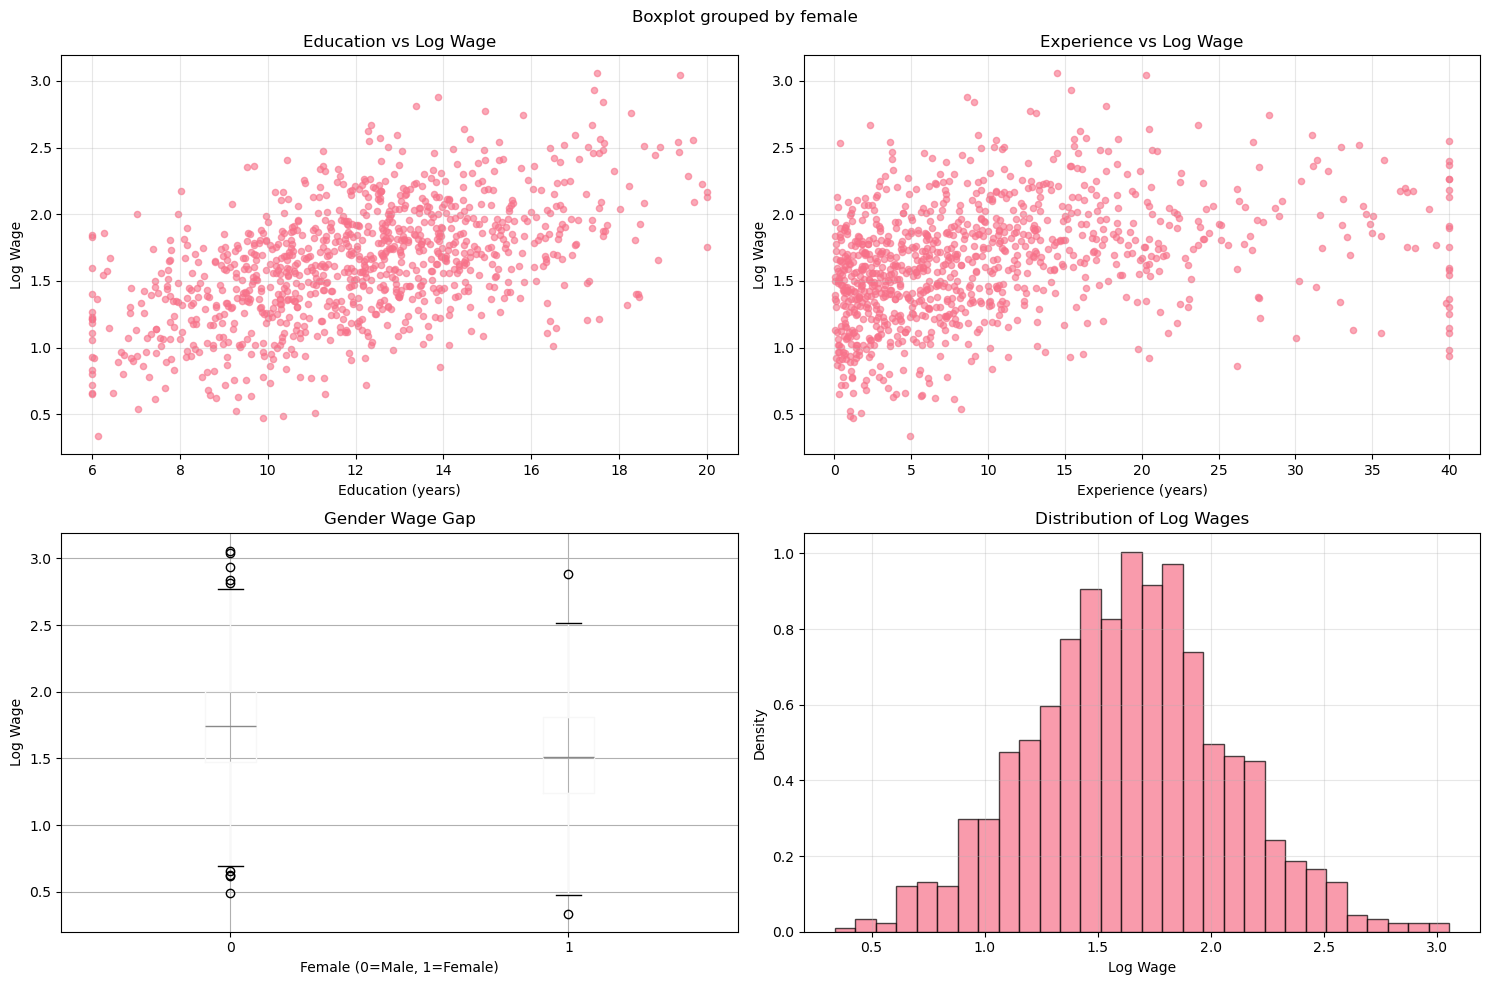

In [4]:
# Create visualization of the synthetic data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Education vs Log Wage
axes[0,0].scatter(data['education'], data['log_wage'], alpha=0.6, s=20)
axes[0,0].set_xlabel('Education (years)')
axes[0,0].set_ylabel('Log Wage')
axes[0,0].set_title('Education vs Log Wage')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Experience vs Log Wage
axes[0,1].scatter(data['experience'], data['log_wage'], alpha=0.6, s=20)
axes[0,1].set_xlabel('Experience (years)')
axes[0,1].set_ylabel('Log Wage')
axes[0,1].set_title('Experience vs Log Wage')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Gender wage gap
data.boxplot(column='log_wage', by='female', ax=axes[1,0])
axes[1,0].set_xlabel('Female (0=Male, 1=Female)')
axes[1,0].set_ylabel('Log Wage')
axes[1,0].set_title('Gender Wage Gap')

# Plot 4: Distribution of log wages
axes[1,1].hist(data['log_wage'], bins=30, density=True, alpha=0.7, edgecolor='black')
axes[1,1].set_xlabel('Log Wage')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Distribution of Log Wages')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Estimate the Model using Statsmodels Formula API

In [5]:
# Estimate the model using statsmodels formula API
print("ESTIMATING THE WAGE EQUATION")
print("=" * 40)

# Define the model using formula notation
formula = 'log_wage ~ education + experience + I(experience**2) + female'
print(f"Model formula: {formula}")

# Fit the model
model = smf.ols(formula, data=data).fit()

# Display the results
print("\nREGRESSION RESULTS:")
print(model.summary())

ESTIMATING THE WAGE EQUATION
Model formula: log_wage ~ education + experience + I(experience**2) + female

REGRESSION RESULTS:
                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     248.4
Date:                Sat, 21 Jun 2025   Prob (F-statistic):          6.22e-148
Time:                        20:15:35   Log-Likelihood:                -240.63
No. Observations:                1000   AIC:                             491.3
Df Residuals:                     995   BIC:                             515.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.9

---

##  Extract Key Statistics for Manual Calculations

In [6]:
# Extract coefficients and statistics for manual hypothesis testing
print("EXTRACTING KEY STATISTICS FOR MANUAL CALCULATIONS")
print("=" * 55)

# Coefficients
coeffs = model.params
std_errors = model.bse
t_stats = model.tvalues
p_values = model.pvalues
conf_int = model.conf_int()

print("COEFFICIENT ESTIMATES:")
print("-" * 25)
for i, var in enumerate(coeffs.index):
    true_val = [TRUE_BETA_0, TRUE_BETA_1, TRUE_BETA_2, TRUE_BETA_3, TRUE_BETA_4][i]
    print(f"{var:15s}: β̂ = {coeffs[var]:8.5f} (True = {true_val:8.5f})")

print("\nSTANDARD ERRORS:")
print("-" * 18)
for var in std_errors.index:
    print(f"{var:15s}: SE = {std_errors[var]:.5f}")

print(f"\nMODEL STATISTICS:")
print("-" * 18)
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adj R-squared: {model.rsquared_adj:.4f}")
print(f"F-statistic: {model.fvalue:.4f}")
print(f"Prob(F-statistic): {model.f_pvalue:.6f}")
print(f"Degrees of freedom: {model.df_model}, {model.df_resid}")
print(f"Number of observations: {model.nobs}")

EXTRACTING KEY STATISTICS FOR MANUAL CALCULATIONS
COEFFICIENT ESTIMATES:
-------------------------
Intercept      : β̂ =  0.54122 (True =  0.50000)
education      : β̂ =  0.07853 (True =  0.08000)
experience     : β̂ =  0.03807 (True =  0.04000)
I(experience ** 2): β̂ = -0.00066 (True = -0.00070)
female         : β̂ = -0.22087 (True = -0.20000)

STANDARD ERRORS:
------------------
Intercept      : SE = 0.04544
education      : SE = 0.00340
experience     : SE = 0.00308
I(experience ** 2): SE = 0.00009
female         : SE = 0.01957

MODEL STATISTICS:
------------------
R-squared: 0.4996
Adj R-squared: 0.4976
F-statistic: 248.3845
Prob(F-statistic): 0.000000
Degrees of freedom: 4.0, 995.0
Number of observations: 1000.0


---

## Individual t-tests - Step by Step

In [7]:
print("INDIVIDUAL t-TESTS: STEP-BY-STEP CALCULATIONS")
print("=" * 50)

print("Test 1: Is the return to education statistically significant?")
print("-" * 60)
print("H₀: β₁ = 0 (education has no effect)")
print("H₁: β₁ ≠ 0 (education has an effect)")
print()

# Extract statistics for education coefficient
beta_1_hat = coeffs['education']
se_beta_1 = std_errors['education']
df = model.df_resid

# Calculate t-statistic manually
t_stat_education = (beta_1_hat - 0) / se_beta_1
print(f"Manual calculation:")
print(f"t = (β̂₁ - 0) / SE(β̂₁) = ({beta_1_hat:.5f} - 0) / {se_beta_1:.5f} = {t_stat_education:.4f}")

# Compare with statsmodels result
print(f"Statsmodels result: {t_stats['education']:.4f}")
print(f"Difference: {abs(t_stat_education - t_stats['education']):.8f}")

# Calculate p-value manually
p_value_manual = 2 * (1 - stats.t.cdf(abs(t_stat_education), df))
print(f"\nP-value calculation:")
print(f"p = 2 × (1 - P(T_{df} ≤ |{t_stat_education:.4f}|)) = {p_value_manual:.6f}")
print(f"Statsmodels p-value: {p_values['education']:.6f}")

# Decision
alpha = 0.05
critical_value = stats.t.ppf(1 - alpha/2, df)
print(f"\nDecision (α = {alpha}):")
print(f"Critical value: ±{critical_value:.4f}")
print(f"Test statistic: {t_stat_education:.4f}")
print(f"Decision: {'Reject H₀' if abs(t_stat_education) > critical_value else 'Fail to reject H₀'}")
print(f"Conclusion: Education {'is' if abs(t_stat_education) > critical_value else 'is not'} statistically significant")

print("\n" + "="*70)

INDIVIDUAL t-TESTS: STEP-BY-STEP CALCULATIONS
Test 1: Is the return to education statistically significant?
------------------------------------------------------------
H₀: β₁ = 0 (education has no effect)
H₁: β₁ ≠ 0 (education has an effect)

Manual calculation:
t = (β̂₁ - 0) / SE(β̂₁) = (0.07853 - 0) / 0.00340 = 23.1304
Statsmodels result: 23.1304
Difference: 0.00000000

P-value calculation:
p = 2 × (1 - P(T_995.0 ≤ |23.1304|)) = 0.000000
Statsmodels p-value: 0.000000

Decision (α = 0.05):
Critical value: ±1.9624
Test statistic: 23.1304
Decision: Reject H₀
Conclusion: Education is statistically significant



---

## More t-tests with Different Hypotheses

In [8]:
print("Test 2: Is the return to education equal to 8%?")
print("-" * 45)
print("H₀: β₁ = 0.08 (return to education is exactly 8%)")
print("H₁: β₁ ≠ 0.08 (return to education is not 8%)")
print()

# Test if education coefficient equals 0.08
hypothesized_value = 0.08
t_stat_8_percent = (beta_1_hat - hypothesized_value) / se_beta_1

print(f"Manual calculation:")
print(f"t = (β̂₁ - 0.08) / SE(β̂₁) = ({beta_1_hat:.5f} - {hypothesized_value}) / {se_beta_1:.5f} = {t_stat_8_percent:.4f}")

# P-value
p_value_8_percent = 2 * (1 - stats.t.cdf(abs(t_stat_8_percent), df))
print(f"P-value: {p_value_8_percent:.4f}")

print(f"\nDecision:")
print(f"Test statistic: {t_stat_8_percent:.4f}")
print(f"Critical value: ±{critical_value:.4f}")
print(f"Decision: {'Reject H₀' if abs(t_stat_8_percent) > critical_value else 'Fail to reject H₀'}")
print(f"Conclusion: The data {'does not support' if abs(t_stat_8_percent) > critical_value else 'is consistent with'} a return to education of exactly 8%")

print("\n" + "="*70)

print("Test 3: Is there a gender wage gap?")
print("-" * 35)
print("H₀: β₄ = 0 (no gender wage gap)")
print("H₁: β₄ ≠ 0 (gender wage gap exists)")
print()

# Test gender coefficient
beta_4_hat = coeffs['female']
se_beta_4 = std_errors['female']
t_stat_gender = (beta_4_hat - 0) / se_beta_4

print(f"Manual calculation:")
print(f"t = (β̂₄ - 0) / SE(β̂₄) = ({beta_4_hat:.5f} - 0) / {se_beta_4:.5f} = {t_stat_gender:.4f}")

p_value_gender = 2 * (1 - stats.t.cdf(abs(t_stat_gender), df))
print(f"P-value: {p_value_gender:.6f}")

print(f"\nDecision:")
print(f"Decision: {'Reject H₀' if abs(t_stat_gender) > critical_value else 'Fail to reject H₀'}")
print(f"Conclusion: {'Strong evidence of' if abs(t_stat_gender) > critical_value else 'No significant evidence of'} a gender wage gap")

Test 2: Is the return to education equal to 8%?
---------------------------------------------
H₀: β₁ = 0.08 (return to education is exactly 8%)
H₁: β₁ ≠ 0.08 (return to education is not 8%)

Manual calculation:
t = (β̂₁ - 0.08) / SE(β̂₁) = (0.07853 - 0.08) / 0.00340 = -0.4331
P-value: 0.6650

Decision:
Test statistic: -0.4331
Critical value: ±1.9624
Decision: Fail to reject H₀
Conclusion: The data is consistent with a return to education of exactly 8%

Test 3: Is there a gender wage gap?
-----------------------------------
H₀: β₄ = 0 (no gender wage gap)
H₁: β₄ ≠ 0 (gender wage gap exists)

Manual calculation:
t = (β̂₄ - 0) / SE(β̂₄) = (-0.22087 - 0) / 0.01957 = -11.2877
P-value: 0.000000

Decision:
Decision: Reject H₀
Conclusion: Strong evidence of a gender wage gap


---

## Joint F-tests - Step by Step

In [9]:
print("JOINT F-TESTS: STEP-BY-STEP CALCULATIONS")
print("=" * 45)

print("Test 1: Joint significance of experience variables")
print("-" * 50)
print("H₀: β₂ = β₃ = 0 (experience has no effect)")
print("H₁: At least one of β₂, β₃ ≠ 0")
print()

# Method 1: Using statsmodels f_test
f_test_experience = model.f_test('experience = 0, I(experience ** 2) = 0')
print(f_test_experience)

JOINT F-TESTS: STEP-BY-STEP CALCULATIONS
Test 1: Joint significance of experience variables
--------------------------------------------------
H₀: β₂ = β₃ = 0 (experience has no effect)
H₁: At least one of β₂, β₃ ≠ 0

<F test: F=148.08846356935473, p=5.030008064190175e-57, df_denom=995, df_num=2>


In [10]:
print("Using statsmodels f_test:")
print(f"F-statistic: {f_test_experience.fvalue:.4f}")
print(f"P-value: {f_test_experience.pvalue:.6f}")
print(f"Degrees of freedom: {f_test_experience.df_num}, {f_test_experience.df_denom}")

Using statsmodels f_test:
F-statistic: 148.0885
P-value: 0.000000
Degrees of freedom: 2.0, 995.0


In [11]:
print("\nMethod 2: Manual calculation using RSS comparison")
print("-" * 55)

# Estimate restricted model (without experience variables)
restricted_formula = 'log_wage ~ education + female'
restricted_model = smf.ols(restricted_formula, data=data).fit()

# Get RSS from both models
RSS_unrestricted = model.ssr
RSS_restricted = restricted_model.ssr
q = 2  # Number of restrictions
n = model.nobs
k = model.df_model  # Number of parameters in unrestricted model (excluding intercept)

print(f"Unrestricted model RSS: {RSS_unrestricted:.4f}")
print(f"Restricted model RSS: {RSS_restricted:.4f}")
print(f"Number of restrictions (q): {q}")
print(f"Sample size (n): {n}")
print(f"Parameters in unrestricted model (k): {k}")


Method 2: Manual calculation using RSS comparison
-------------------------------------------------------
Unrestricted model RSS: 94.7405
Restricted model RSS: 122.9415
Number of restrictions (q): 2
Sample size (n): 1000.0
Parameters in unrestricted model (k): 4.0


In [12]:
# Calculate F-statistic manually
F_manual = ((RSS_restricted - RSS_unrestricted) / q) / (RSS_unrestricted / (n - k - 1))
print(f"\nManual F-statistic calculation:")
print(f"F = [(RSS_r - RSS_u) / q] / [RSS_u / (n - k - 1)]")
print(f"F = [({RSS_restricted:.4f} - {RSS_unrestricted:.4f}) / {q}] / [{RSS_unrestricted:.4f} / ({n} - {k} - 1)]")
print(f"F = [{RSS_restricted - RSS_unrestricted:.4f} / {q}] / [{RSS_unrestricted:.4f} / {n - k - 1}]")
print(f"F = {(RSS_restricted - RSS_unrestricted) / q:.4f} / {RSS_unrestricted / (n - k - 1):.6f}")
print(f"F = {F_manual:.4f}")

# Compare methods
print(f"\nComparison:")
print(f"Statsmodels F-statistic: {f_test_experience.fvalue:.4f}")
print(f"Manual F-statistic: {F_manual:.4f}")
print(f"Difference: {abs(f_test_experience.fvalue - F_manual):.8f}")

# P-value and decision
F_critical = stats.f.ppf(0.95, q, n - k - 1)
p_value_F = 1 - stats.f.cdf(F_manual, q, n - k - 1)

print(f"\nDecision making:")
print(f"Critical value (α=0.05): {F_critical:.4f}")
print(f"P-value: {p_value_F:.6f}")
print(f"Decision: {'Reject H₀' if F_manual > F_critical else 'Fail to reject H₀'}")
print(f"Conclusion: Experience variables are {'jointly significant' if F_manual > F_critical else 'not jointly significant'}")


Manual F-statistic calculation:
F = [(RSS_r - RSS_u) / q] / [RSS_u / (n - k - 1)]
F = [(122.9415 - 94.7405) / 2] / [94.7405 / (1000.0 - 4.0 - 1)]
F = [28.2010 / 2] / [94.7405 / 995.0]
F = 14.1005 / 0.095217
F = 148.0885

Comparison:
Statsmodels F-statistic: 148.0885
Manual F-statistic: 148.0885
Difference: 0.00000000

Decision making:
Critical value (α=0.05): 3.0048
P-value: 0.000000
Decision: Reject H₀
Conclusion: Experience variables are jointly significant


---

## Testing Economic Hypotheses

In [13]:
print("TESTING SPECIFIC ECONOMIC HYPOTHESES")
print("=" * 40)

print("Test 1: Equal returns to education and experience")
print("-" * 50)
print("H₀: β₁ = β₂ (education and experience have equal returns)")
print("H₁: β₁ ≠ β₂")
print()

# Using statsmodels hypothesis testing
hypothesis_test = model.f_test('education = experience')
print(f"F-statistic: {hypothesis_test.fvalue:.4f}")
print(f"P-value: {hypothesis_test.pvalue:.4f}")

# Manual calculation using Wald test
beta_1 = coeffs['education']
beta_2 = coeffs['experience']
se_1 = std_errors['education']
se_2 = std_errors['experience']

# Get covariance matrix
cov_matrix = model.cov_params()
cov_12 = cov_matrix.loc['education', 'experience']

# Standard error of the difference
se_difference = np.sqrt(se_1**2 + se_2**2 - 2*cov_12)
t_stat_equal = (beta_1 - beta_2) / se_difference

print(f"\nManual calculation:")
print(f"β̂₁ - β̂₂ = {beta_1:.5f} - {beta_2:.5f} = {beta_1 - beta_2:.5f}")
print(f"SE(β̂₁ - β̂₂) = √(SE₁² + SE₂² - 2×Cov(β̂₁,β̂₂)) = {se_difference:.5f}")
print(f"t = (β̂₁ - β̂₂) / SE(β̂₁ - β̂₂) = {t_stat_equal:.4f}")

p_value_equal = 2 * (1 - stats.t.cdf(abs(t_stat_equal), df))
print(f"P-value: {p_value_equal:.4f}")

print("\n" + "="*70)

print("Test 2: Testing multiple coefficient restrictions")
print("-" * 45)
print("H₀: β₁ = 0.08 AND β₄ = -0.2 (both parameters equal their true values)")
print("H₁: At least one restriction is violated")
print()

# Joint test of multiple restrictions
joint_test = model.f_test(['education = 0.08', 'female = -0.2'])
print(f"Joint F-test results:")
print(f"F-statistic: {joint_test.fvalue:.4f}")
print(f"P-value: {joint_test.pvalue:.4f}")
print(f"Degrees of freedom: {joint_test.df_num}, {joint_test.df_denom}")

print(f"\nDecision:")
alpha = 0.05
F_critical_joint = stats.f.ppf(1-alpha, joint_test.df_num, joint_test.df_denom)
print(f"Critical value (α={alpha}): {F_critical_joint:.4f}")
print(f"Decision: {'Reject H₀' if joint_test.fvalue> F_critical_joint else 'Fail to reject H₀'}")

TESTING SPECIFIC ECONOMIC HYPOTHESES
Test 1: Equal returns to education and experience
--------------------------------------------------
H₀: β₁ = β₂ (education and experience have equal returns)
H₁: β₁ ≠ β₂

F-statistic: 72.8874
P-value: 0.0000

Manual calculation:
β̂₁ - β̂₂ = 0.07853 - 0.03807 = 0.04046
SE(β̂₁ - β̂₂) = √(SE₁² + SE₂² - 2×Cov(β̂₁,β̂₂)) = 0.00474
t = (β̂₁ - β̂₂) / SE(β̂₁ - β̂₂) = 8.5374
P-value: 0.0000

Test 2: Testing multiple coefficient restrictions
---------------------------------------------
H₀: β₁ = 0.08 AND β₄ = -0.2 (both parameters equal their true values)
H₁: At least one restriction is violated

Joint F-test results:
F-statistic: 0.6662
P-value: 0.5139
Degrees of freedom: 2.0, 995.0

Decision:
Critical value (α=0.05): 3.0048
Decision: Fail to reject H₀


---

## Confidence Intervals - Manual Calculation

In [14]:
print("CONFIDENCE INTERVALS: MANUAL CALCULATIONS")
print("=" * 45)

# 95% Confidence intervals for all coefficients
alpha = 0.05
t_critical = stats.t.ppf(1 - alpha/2, df)

print(f"95% Confidence Intervals (α = {alpha})")
print(f"Critical value: ±{t_critical:.4f}")
print(f"Formula: β̂ ± t_{alpha/2} × SE(β̂)")
print()

print("Manual calculations:")
print("-" * 20)
for var in coeffs.index:
    coeff = coeffs[var]
    se = std_errors[var]
    margin_error = t_critical * se
    ci_lower = coeff - margin_error
    ci_upper = coeff + margin_error
    
    # Get statsmodels CI for comparison
    sm_ci_lower = conf_int.loc[var, 0]
    sm_ci_upper = conf_int.loc[var, 1]
    
    print(f"{var:15s}:")
    print(f"  Manual CI: [{ci_lower:7.4f}, {ci_upper:7.4f}]")
    print(f"  Statsmodels: [{sm_ci_lower:7.4f}, {sm_ci_upper:7.4f}]")
    print(f"  Difference: {abs(ci_lower - sm_ci_lower):.8f}, {abs(ci_upper - sm_ci_upper):.8f}")
    print()

print("Economic Interpretation:")
print("-" * 25)
print(f"• Education: We are 95% confident that each additional year of education")
print(f"  increases wages by between {conf_int.loc['education', 0]*100:.2f}% and {conf_int.loc['education', 1]*100:.2f}%")
print(f"• Gender gap: We are 95% confident that women earn between")
print(f"  {conf_int.loc['female', 0]*100:.1f}% and {conf_int.loc['female', 1]*100:.1f}% less than men")

CONFIDENCE INTERVALS: MANUAL CALCULATIONS
95% Confidence Intervals (α = 0.05)
Critical value: ±1.9624
Formula: β̂ ± t_0.025 × SE(β̂)

Manual calculations:
--------------------
Intercept      :
  Manual CI: [ 0.4520,  0.6304]
  Statsmodels: [ 0.4520,  0.6304]
  Difference: 0.00000000, 0.00000000

education      :
  Manual CI: [ 0.0719,  0.0852]
  Statsmodels: [ 0.0719,  0.0852]
  Difference: 0.00000000, 0.00000000

experience     :
  Manual CI: [ 0.0320,  0.0441]
  Statsmodels: [ 0.0320,  0.0441]
  Difference: 0.00000000, 0.00000000

I(experience ** 2):
  Manual CI: [-0.0008, -0.0005]
  Statsmodels: [-0.0008, -0.0005]
  Difference: 0.00000000, 0.00000000

female         :
  Manual CI: [-0.2593, -0.1825]
  Statsmodels: [-0.2593, -0.1825]
  Difference: 0.00000000, 0.00000000

Economic Interpretation:
-------------------------
• Education: We are 95% confident that each additional year of education
  increases wages by between 7.19% and 8.52%
• Gender gap: We are 95% confident that women e

---

## Model Diagnostics and Assumption Testing

MODEL DIAGNOSTICS AND ASSUMPTION TESTING


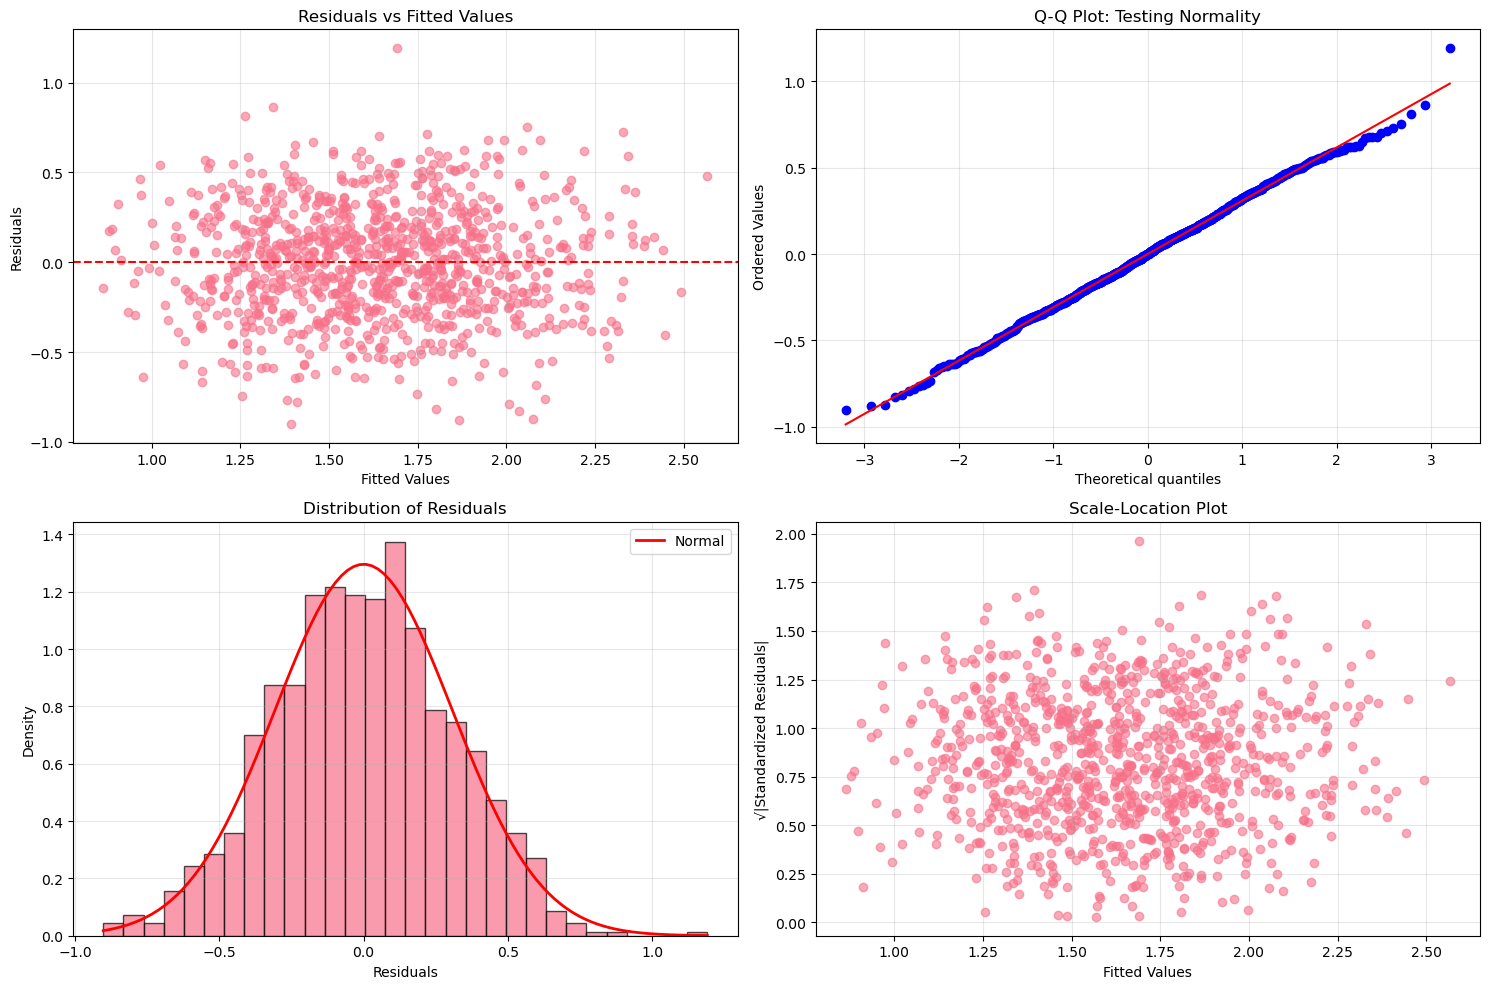


Statistical Tests for Assumptions:
-----------------------------------
Shapiro-Wilk test for normality:
  Test statistic: 0.9984
  P-value: 0.4732
  Result: Fail to reject normality

Breusch-Pagan test for heteroscedasticity:
  LM statistic: 6.6020
  P-value: 0.1585
  Result: Fail to reject homoscedasticity


In [28]:
print("MODEL DIAGNOSTICS AND ASSUMPTION TESTING")
print("=" * 45)

# Get residuals
residuals = model.resid
fitted_values = model.fittedvalues
standardized_residuals = model.resid_pearson

# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Residuals vs Fitted
axes[0,0].scatter(fitted_values, residuals, alpha=0.6)
axes[0,0].axhline(y=0, color='red', linestyle='--')
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted Values')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Q-Q plot for normality
stats.probplot(residuals, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot: Testing Normality')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Histogram of residuals
axes[1,0].hist(residuals, bins=30, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[1,0].plot(x, stats.norm.pdf(x, 0, np.std(residuals)), 'r-', linewidth=2, label='Normal')
axes[1,0].set_xlabel('Residuals')
axes[1,0].set_ylabel('Density')
axes[1,0].set_title('Distribution of Residuals')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Scale-Location plot
sqrt_abs_resid = np.sqrt(np.abs(standardized_residuals))
axes[1,1].scatter(fitted_values, sqrt_abs_resid, alpha=0.6)
axes[1,1].set_xlabel('Fitted Values')
axes[1,1].set_ylabel('√|Standardized Residuals|')
axes[1,1].set_title('Scale-Location Plot')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical tests for assumptions
print("\nStatistical Tests for Assumptions:")
print("-" * 35)

# Normality test
shapiro_stat, shapiro_p = stats.shapiro(residuals[:1000])  # Shapiro-Wilk (max 5000 obs)
print(f"Shapiro-Wilk test for normality:")
print(f"  Test statistic: {shapiro_stat:.4f}")
print(f"  P-value: {shapiro_p:.4f}")
print(f"  Result: {'Reject normality' if shapiro_p < 0.05 else 'Fail to reject normality'}")

# Breusch-Pagan test for heteroscedasticity
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_p, bp_f_stat, bp_f_p = het_breuschpagan(residuals, model.model.exog)
print(f"\nBreusch-Pagan test for heteroscedasticity:")
print(f"  LM statistic: {bp_stat:.4f}")
print(f"  P-value: {bp_p:.4f}")
print(f"  Result: {'Reject homoscedasticity' if bp_p < 0.05 else 'Fail to reject homoscedasticity'}")

---

## Summary and Economic Conclusions

In [30]:
print("SUMMARY OF HYPOTHESIS TESTING RESULTS")
print("=" * 40)

print("1. INDIVIDUAL COEFFICIENT TESTS:")
print("   " + "-" * 30)
for var in coeffs.index:
    if var == 'Intercept':
        continue
    t_stat = t_stats[var]
    p_val = p_values[var]
    significant = p_val < 0.05
    print(f"   {var:15s}: t = {t_stat:7.3f}, p = {p_val:.4f} {'***' if significant else ''}")

print(f"\n2. JOINT TESTS:")
print("   " + "-" * 15)
print(f"   Experience variables: F = {f_test_experience.fvalue:.3f}, p = {f_test_experience.pvalue:.4f}")
print(f"   Overall model: F = {model.fvalue:.3f}, p = {model.f_pvalue:.4f}")

print(f"\n3. ECONOMIC INTERPRETATION:")
print("   " + "-" * 25)
print(f"   • Return to education: {coeffs['education']*100:.2f}% per year")
print(f"   • Return to experience: {coeffs['experience']*100:.2f}% per year")
print(f"   • Experience diminishing returns: {coeffs['I(experience ** 2)']*100:.4f}% per year²")
print(f"   • Gender wage gap: {coeffs['female']*100:.1f}%")

print(f"\n4. MODEL FIT:")
print("   " + "-" * 12)
print(f"   • R-squared: {model.rsquared:.3f} ({model.rsquared*100:.1f}% of variance explained)")
print(f"   • Adjusted R-squared: {model.rsquared_adj:.3f}")
print(f"   • Standard error: {np.sqrt(model.mse_resid):.3f}")

print(f"\n5. COMPARISON WITH TRUE VALUES:")
print("   " + "-" * 28)
true_values = [TRUE_BETA_0, TRUE_BETA_1, TRUE_BETA_2, TRUE_BETA_3, TRUE_BETA_4]
param_names = ['Intercept', 'Education', 'Experience', 'Experience²', 'Female']

for i, (name, true_val) in enumerate(zip(param_names, true_values)):
    estimated = coeffs.iloc[i]
    difference = estimated - true_val
    print(f"   {name:12s}: True = {true_val:7.4f}, Est = {estimated:7.4f}, Diff = {difference:8.4f}")

print(f"\n 
CONCLUSION:")
print(f"   Our hypothesis testing procedures successfully detected the relationships")
print(f"   built into the synthetic data, validating the econometric methodology!")

SUMMARY OF HYPOTHESIS TESTING RESULTS
1. INDIVIDUAL COEFFICIENT TESTS:
   ------------------------------
   education      : t =  23.130, p = 0.0000 ***
   experience     : t =  12.360, p = 0.0000 ***
   I(experience ** 2): t =  -7.501, p = 0.0000 ***
   female         : t = -11.288, p = 0.0000 ***

2. JOINT TESTS:
   ---------------
   Experience variables: F = 148.088, p = 0.0000
   Overall model: F = 248.385, p = 0.0000

3. ECONOMIC INTERPRETATION:
   -------------------------
   • Return to education: 7.85% per year
   • Return to experience: 3.81% per year
   • Experience diminishing returns: -0.0656% per year²
   • Gender wage gap: -22.1%

4. MODEL FIT:
   ------------
   • R-squared: 0.500 (50.0% of variance explained)
   • Adjusted R-squared: 0.498
   • Standard error: 0.309

5. COMPARISON WITH TRUE VALUES:
   ----------------------------
   Intercept   : True =  0.5000, Est =  0.5412, Diff =   0.0412
   Education   : True =  0.0800, Est =  0.0785, Diff =  -0.0015
   Experience